# Local SFH Sky-Residual Investigation

Goal: test whether the pointing-scale SFH `AGE` artifacts in the 4800-8900 A nGIST run are consistent with red-sky residual contamination, and identify the smallest useful nGIST/pPXF-side follow-up tests.

Scope of this notebook:

- local products only under `/Users/Igniz/Desktop/ICRAR/further`;
- main products are `v3tk_v7.6.8/{GALID}/{GALID}_sfh_maps.fits`, `{GALID}_sfh_weights.fits`, and `{GALID}_spatial_binning_maps.fits`;
- no Setonix retrieval and no use of `scp_*.sh`;
- the `~8103 A` feature is treated as a hypothesis, not as a causal result, because the local map/weight products do not contain the original spectra or residual vectors, and because observed-frame sky features must be converted to rest frame before comparing to nGIST masks.


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import ndimage, stats
from IPython.display import display, Markdown

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': False,
    'font.size': 9,
})

ROOT = Path('/Users/Igniz/Desktop/ICRAR/further')
RUN_ROOT = ROOT / 'v3tk_v7.6.8'
CONFIG_ROOT = Path('/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup')
FOCUS_GALAXIES = ['NGC4064', 'NGC4383', 'NGC4396']
OLD_AGE_GYR = 12.5

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
print('ROOT:', ROOT)
print('RUN_ROOT exists:', RUN_ROOT.exists())


ROOT: /Users/Igniz/Desktop/ICRAR/further
RUN_ROOT exists: True


## Local Product Inventory

This first cell records which galaxies have the minimum map, weight, and spatial-binning products needed for this map-level diagnosis. Galaxies without complete SFH map/weight/binning triplets are not included in the ranking.


In [2]:
def inventory_products(run_root=RUN_ROOT):
    rows = []
    for gal_dir in sorted(p for p in run_root.iterdir() if p.is_dir()):
        gal = gal_dir.name
        row = {
            'galaxy': gal,
            'sfh_maps': (gal_dir / f'{gal}_sfh_maps.fits').exists(),
            'sfh_weights': (gal_dir / f'{gal}_sfh_weights.fits').exists(),
            'spatial_binning': (gal_dir / f'{gal}_spatial_binning_maps.fits').exists(),
            'kin_maps': (gal_dir / f'{gal}_kin_maps.fits').exists(),
            'gas_bin_maps': (gal_dir / f'{gal}_gas_BIN_maps.fits').exists() or (gal_dir / f'{gal}_gas_bin_maps.fits').exists(),
            'sfh_bestfit': (gal_dir / f'{gal}_sfh-bestfit.fits').exists() or (gal_dir / f'{gal}_sfh_bestfit.fits').exists(),
        }
        row['complete_for_this_notebook'] = row['sfh_maps'] and row['sfh_weights'] and row['spatial_binning']
        rows.append(row)
    return pd.DataFrame(rows)

inventory = inventory_products()
display(inventory)
print('Complete SFH triplets:', int(inventory['complete_for_this_notebook'].sum()), 'of', len(inventory))
print('Missing local SFH bestfit/GOODPIX products among complete galaxies:', int((inventory['complete_for_this_notebook'] & ~inventory['sfh_bestfit']).sum()))


,galaxy,sfh_maps,sfh_weights,spatial_binning,kin_maps,gas_bin_maps,sfh_bestfit,complete_for_this_notebook
0,IC3392,True,True,True,True,True,False,True
1,NGC4064,True,True,True,True,True,False,True
2,NGC4189,True,True,True,True,True,False,True
3,NGC4192,True,True,True,True,True,False,True
4,NGC4293,True,True,True,True,True,False,True
5,NGC4294,True,True,True,True,True,False,True
6,NGC4298,False,False,True,True,False,False,False
7,NGC4302,True,True,True,True,False,False,True
8,NGC4330,False,False,True,True,False,False,False
9,NGC4351,True,True,True,True,True,False,True


Complete SFH triplets: 22 of 26
Missing local SFH bestfit/GOODPIX products among complete galaxies: 22


## Current Method Context From Local Configs And References

The local config setup is used only to interpret the existing products. The diagnosis below does not rerun nGIST.


In [3]:
def read_text(path):
    path = Path(path)
    return path.read_text(errors='replace') if path.exists() else ''

def extract_block(text, heading):
    lines = text.splitlines()
    start = None
    for i, line in enumerate(lines):
        if line.strip() == f'{heading}:':
            start = i
            break
    if start is None:
        return ''
    end = len(lines)
    for j in range(start + 1, len(lines)):
        if lines[j] and not lines[j].startswith(' ') and lines[j].endswith(':'):
            end = j
            break
    return '\n'.join(lines[start:end])

def compact_config_summary(gal='NGC4064'):
    config_path = CONFIG_ROOT / f'{gal}_MAUVE_MasterConfig_v7.6.8_setonix.yaml'
    text = read_text(config_path)
    rows = []
    for block in ['READ_DATA', 'SPATIAL_BINNING', 'KIN', 'GAS', 'SFH']:
        btxt = extract_block(text, block)
        for key in ['LMIN_TOT', 'LMAX_TOT', 'LMIN_SNR', 'LMAX_SNR', 'TARGET_SNR', 'SPEC_MASK', 'LMIN', 'LMAX', 'MDEG', 'REGUL', 'FIXED', 'LIBRARY', 'NOISE', 'DOCLEAN', 'EMI_FILE']:
            m = re.search(rf'^\s+{re.escape(key)}:\s*(.*)$', btxt, flags=re.MULTILINE)
            if m:
                rows.append({'block': block, 'key': key, 'value': m.group(1).strip()})
    return config_path, pd.DataFrame(rows)

config_path, config_summary = compact_config_summary('NGC4064')
print('Config inspected:', config_path)
display(config_summary)

mask_path = CONFIG_ROOT / 'specMask_KIN_narrow10'
mask_text = read_text(mask_path)
sky_lines = []
for line in mask_text.splitlines():
    if 'sky' not in line or line.strip().startswith('#'):
        continue
    parts = line.split()
    if len(parts) >= 3:
        try:
            lam = float(parts[0])
            width = float(parts[1])
        except ValueError:
            continue
        if 7900 <= lam <= 8200:
            sky_lines.append({'lambda_A': lam, 'width_A': width, 'comment': ' '.join(parts[2:])})

print('Sky-mask entries in 7900-8200 A from specMask_KIN_narrow10:')
display(pd.DataFrame(sky_lines))


Config inspected: /Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/NGC4064_MAUVE_MasterConfig_v7.6.8_setonix.yaml


,block,key,value
0,READ_DATA,LMIN_TOT,4800
1,READ_DATA,LMAX_TOT,8900
2,READ_DATA,LMIN_SNR,4800
3,READ_DATA,LMAX_SNR,8900
4,SPATIAL_BINNING,TARGET_SNR,40.0
5,KIN,SPEC_MASK,specMask_KIN_narrow10
6,KIN,LMIN,4800
7,KIN,LMAX,8900
8,KIN,MDEG,0
9,KIN,LIBRARY,EMILES_baseFe_EMLINES/


Sky-mask entries in 7900-8200 A from specMask_KIN_narrow10:


,lambda_A,width_A,comment
0,7913.680000,10.0,sky
1,7913.735000,10.0,sky
2,7920.982000,10.0,sky
3,7921.019000,10.0,sky
4,7921.107000,10.0,sky
5,7921.219000,10.0,sky
6,7930.873000,10.0,sky
7,7931.383000,10.0,sky
8,7931.542000,10.0,sky
9,7931.994000,10.0,sky


## Observed-Frame Sky Lines Versus Rest-Frame Masks

Important frame convention: the mapviewer spectra are inspected in observed wavelength, while the nGIST spectral masks in this setup are specified in the rest frame. The local master config states that spectra are shifted to rest frame using `GENERAL.REDSHIFT`, and `specMask_KIN_narrow10` states that mask wavelengths are rest-frame ranges. Therefore, a residual seen at observed wavelength `lambda_obs` should be compared to a rest-frame mask center near:

`lambda_rest = lambda_obs / (1 + z)`

This matters for the `~8103 A` feature: for NGC4064, `z=0.003025`, so an observed-frame `8103 A` residual corresponds to about `8078.5 A` in the rest frame, not `8103 A`. A rest-frame mask at `8102-8103 A` would instead target an observed feature around `8126-8127 A` for NGC4064. The table below checks this explicitly for the focus galaxies.


In [4]:
def read_redshifts_from_configs(config_root=CONFIG_ROOT):
    rows = []
    for cfg in sorted(config_root.glob('*_MAUVE_MasterConfig_v7.6.8_setonix.yaml')):
        text = read_text(cfg)
        run_id = re.search(r'^\s+RUN_ID:\s*(\S+)\s*$', text, flags=re.MULTILINE)
        redshift = re.search(r'^\s+REDSHIFT:\s*([-+0-9.eE]+)\s*$', text, flags=re.MULTILINE)
        if run_id and redshift:
            rows.append({'galaxy': run_id.group(1), 'redshift': float(redshift.group(1)), 'config': str(cfg)})
    return pd.DataFrame(rows)


def parse_sky_mask(mask_path=CONFIG_ROOT / 'specMask_KIN_narrow10'):
    rows = []
    for line in read_text(mask_path).splitlines():
        if line.strip().startswith('#') or 'sky' not in line:
            continue
        parts = line.split()
        if len(parts) < 3:
            continue
        try:
            lam = float(parts[0])
            width = float(parts[1])
        except ValueError:
            continue
        rows.append({
            'mask_center_rest_A': lam,
            'width_A': width,
            'mask_min_rest_A': lam - width / 2,
            'mask_max_rest_A': lam + width / 2,
            'comment': ' '.join(parts[2:]),
        })
    return pd.DataFrame(rows)

redshift_table = read_redshifts_from_configs()
sky_mask = parse_sky_mask()
OBS_FEATURE_A = 8103.08

frame_rows = []
for gal in FOCUS_GALAXIES:
    z = float(redshift_table.loc[redshift_table['galaxy'] == gal, 'redshift'].iloc[0])
    rest_feature = OBS_FEATURE_A / (1 + z)
    nearby = sky_mask.assign(distance_A=np.abs(sky_mask['mask_center_rest_A'] - rest_feature)).sort_values('distance_A').head(5)
    covered = ((sky_mask['mask_min_rest_A'] <= rest_feature) & (rest_feature <= sky_mask['mask_max_rest_A'])).any()
    nearest = nearby.iloc[0]
    frame_rows.append({
        'galaxy': gal,
        'redshift': z,
        'observed_feature_A': OBS_FEATURE_A,
        'feature_rest_A': rest_feature,
        'nearest_mask_center_rest_A': nearest['mask_center_rest_A'],
        'nearest_mask_width_A': nearest['width_A'],
        'nearest_distance_A': nearest['distance_A'],
        'covered_by_current_rest_mask': bool(covered),
        'rest_8102_mask_observed_A_at_this_z': 8102.5 * (1 + z),
    })

frame_check = pd.DataFrame(frame_rows)
display(frame_check.style.format({
    'redshift': '{:.6f}',
    'observed_feature_A': '{:.2f}',
    'feature_rest_A': '{:.2f}',
    'nearest_mask_center_rest_A': '{:.2f}',
    'nearest_mask_width_A': '{:.1f}',
    'nearest_distance_A': '{:.2f}',
    'rest_8102_mask_observed_A_at_this_z': '{:.2f}',
}))

print('Nearest current rest-frame sky masks to the converted feature:')
for gal in FOCUS_GALAXIES:
    z = float(redshift_table.loc[redshift_table['galaxy'] == gal, 'redshift'].iloc[0])
    rest_feature = OBS_FEATURE_A / (1 + z)
    nearby = sky_mask.assign(distance_A=np.abs(sky_mask['mask_center_rest_A'] - rest_feature)).sort_values('distance_A').head(6)
    print(f'\n{gal}: observed {OBS_FEATURE_A:.2f} A -> rest {rest_feature:.2f} A')
    display(nearby[['mask_center_rest_A', 'width_A', 'mask_min_rest_A', 'mask_max_rest_A', 'distance_A']].style.format(precision=2))


,galaxy,redshift,observed_feature_A,feature_rest_A,nearest_mask_center_rest_A,nearest_mask_width_A,nearest_distance_A,covered_by_current_rest_mask,rest_8102_mask_observed_A_at_this_z
0,NGC4064,0.003025,8103.08,8078.64,8062.32,10.0,16.32,False,8127.01
1,NGC4383,0.005704,8103.08,8057.12,8061.93,10.0,4.81,True,8148.72
2,NGC4396,-0.000417,8103.08,8106.46,8102.76,10.0,3.70,True,8099.12


Nearest current rest-frame sky masks to the converted feature:

NGC4064: observed 8103.08 A -> rest 8078.64 A


,mask_center_rest_A,width_A,mask_min_rest_A,mask_max_rest_A,distance_A
116,8062.32,10.00,8057.32,8067.32,16.32
115,8061.93,10.00,8056.93,8066.93,16.71
117,8102.24,10.00,8097.24,8107.24,23.60
118,8102.76,10.00,8097.76,8107.76,24.12
114,8052.08,10.00,8047.08,8057.08,26.57
113,8051.97,10.00,8046.97,8056.97,26.68



NGC4383: observed 8103.08 A -> rest 8057.12 A


,mask_center_rest_A,width_A,mask_min_rest_A,mask_max_rest_A,distance_A
115,8061.93,10.00,8056.93,8066.93,4.81
114,8052.08,10.00,8047.08,8057.08,5.05
113,8051.97,10.00,8046.97,8056.97,5.16
116,8062.32,10.00,8057.32,8067.32,5.20
112,8025.95,10.00,8020.95,8030.95,31.17
111,8025.67,10.00,8020.67,8030.67,31.46



NGC4396: observed 8103.08 A -> rest 8106.46 A


,mask_center_rest_A,width_A,mask_min_rest_A,mask_max_rest_A,distance_A
118,8102.76,10.00,8097.76,8107.76,3.70
117,8102.24,10.00,8097.24,8107.24,4.22
116,8062.32,10.00,8057.32,8067.32,44.14
115,8061.93,10.00,8056.93,8066.93,44.53
114,8052.08,10.00,8047.08,8057.08,54.38
113,8051.97,10.00,8046.97,8056.97,54.49


Reference points used for interpretation:

- [GIST SFH docs](https://abittner.gitlab.io/thegistpipeline/documentation/modules/sfh.html) define `_sfh_weights.fits` as template weights with one row per bin, and define `GOODPIX` as part of `_sfh-bestfit.fits`. The local product set here has the weights but not the bestfit/GOODPIX products for the complete galaxies.
- [pPXF software documentation](https://users.physics.ox.ac.uk/~cappellari/software/) lists regularized template weights, iterative clipping, additive/multiplicative polynomials, and inclusion of a sky spectrum as supported features. The installed local pPXF is checked below.
- [Cappellari 2017](https://academic.oup.com/mnras/article/466/1/798/2566728) frames SFH recovery from full-spectrum fitting as an ill-conditioned inverse problem where regularization selects among degenerate solutions consistent with the data.
- Local frame convention: mapviewer wavelengths are observed-frame, but the nGIST masks used here are rest-frame. For a sky residual seen at observed `lambda_obs`, compare against a rest-frame mask at `lambda_obs/(1+z)` unless the nGIST mask-building code is verified to special-case `sky` rows.
- [ESO's MUSE sky residual note](https://www.eso.org/sci/publications/announcements/sciann16040.html) explicitly notes that MUSE archive cubes are sky-subtracted but can retain sky-line residuals redward of 7000 A, reducible with ZAP/muse_zap.


In [5]:
try:
    import ppxf
    import ppxf.ppxf as ppxf_mod
    import inspect
    print('Installed pPXF version:', getattr(ppxf, '__version__', 'unknown'))
    print('Installed pPXF path:', ppxf_mod.__file__)
    signature = str(inspect.signature(ppxf_mod.ppxf))
    for keyword in ['goodpixels', 'clean', 'sky', 'regul']:
        print(f'{keyword!r} in pPXF signature:', keyword in signature)
except Exception as exc:
    print('Could not inspect installed pPXF:', repr(exc))


Installed pPXF version: 9.4.2
Installed pPXF path: /opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/ppxf/ppxf.py
'goodpixels' in pPXF signature: True
'clean' in pPXF signature: True
'sky' in pPXF signature: True
'regul' in pPXF signature: True


## Diagnostic Helpers

The central derived quantity is the old-template weight fraction per bin:

`old_fraction = sum(weights where 10**GRID.LOGAGE >= 12.5 Gyr) / sum(all weights)`

This is then mapped back to spaxels through the spatial-binning `BINID` map. The rest of the metrics are intentionally map-level and falsifiable with local files: high `RED_CHI2`, coherent half-plane/quadrant contrasts, edge-vs-core contrasts, and correlations against `SNR_POSTFIT`, `EBV`, bin size, and distance from the valid-map edge.


In [6]:
def finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]


def robust_iqr(values):
    vals = finite_values(values)
    if vals.size < 2:
        return np.nan
    q25, q75 = np.nanpercentile(vals, [25, 75])
    return q75 - q25


def robust_limits(values, percentiles=(2, 98), pad_fraction=0.04, fallback=(0.0, 1.0)):
    vals = finite_values(values)
    if vals.size == 0:
        return fallback
    lo, hi = np.nanpercentile(vals, percentiles)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        med = np.nanmedian(vals)
        spread = np.nanstd(vals)
        if not np.isfinite(spread) or spread <= 0:
            spread = 1.0
        lo, hi = med - spread, med + spread
    pad = (hi - lo) * pad_fraction
    return lo - pad, hi + pad


def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 5 or np.nanstd(x[m]) == 0 or np.nanstd(y[m]) == 0:
        return np.nan
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return stats.spearmanr(x[m], y[m]).statistic


def read_sfh_triplet(gal):
    base = RUN_ROOT / gal
    paths = {
        'maps': base / f'{gal}_sfh_maps.fits',
        'weights': base / f'{gal}_sfh_weights.fits',
        'binning': base / f'{gal}_spatial_binning_maps.fits',
    }
    for label, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(f'Missing {label}: {path}')

    with fits.open(paths['maps'], memmap=False) as hdul:
        maps = {name: np.array(hdul[name].data, dtype=float) for name in ['AGE', 'SNR_POSTFIT', 'RED_CHI2', 'EBV']}
    with fits.open(paths['binning'], memmap=False) as hdul:
        binning = {name: np.array(hdul[name].data, dtype=float) for name in ['BINID', 'FLUX', 'SNR', 'SNRBIN', 'XBIN', 'YBIN'] if name in hdul}
    with fits.open(paths['weights'], memmap=False) as hdul:
        weights = np.array(hdul['WEIGHTS'].data['WEIGHTS'], dtype=float)
        grid = pd.DataFrame({
            'LOGAGE': np.array(hdul['GRID'].data['LOGAGE'], dtype=float),
            'AGE_GYR': 10 ** np.array(hdul['GRID'].data['LOGAGE'], dtype=float),
            'METAL': np.array(hdul['GRID'].data['METAL'], dtype=float),
            'ALPHA': np.array(hdul['GRID'].data['ALPHA'], dtype=float),
        })
    return paths, maps, binning, weights, grid


def old_fraction_from_weights(weights, grid, old_age_gyr=OLD_AGE_GYR):
    weights = np.asarray(weights, dtype=float)
    old_mask = np.asarray(grid['AGE_GYR'] >= old_age_gyr)
    total = np.nansum(weights, axis=1)
    old = np.full(weights.shape[0], np.nan, dtype=float)
    ok = total > 0
    old[ok] = np.nansum(weights[ok][:, old_mask], axis=1) / total[ok]
    return old


def bin_mean_from_map(values, binid, n_bins):
    valid = np.isfinite(values) & np.isfinite(binid) & (binid >= 0) & (binid < n_bins)
    ids = binid[valid].astype(int)
    vals = np.asarray(values, dtype=float)[valid]
    counts = np.bincount(ids, minlength=n_bins).astype(float)
    sums = np.bincount(ids, weights=vals, minlength=n_bins).astype(float)
    out = np.full(n_bins, np.nan)
    nz = counts > 0
    out[nz] = sums[nz] / counts[nz]
    return out, counts


def best_halfplane_split(metric, x, y, valid, min_fraction=0.2):
    vals = np.asarray(metric, dtype=float)[valid]
    xv = np.asarray(x, dtype=float)[valid]
    yv = np.asarray(y, dtype=float)[valid]
    good = np.isfinite(vals) & np.isfinite(xv) & np.isfinite(yv)
    vals, xv, yv = vals[good], xv[good], yv[good]
    if vals.size < 500:
        return {'norm': np.nan, 'angle_deg': np.nan, 'cut': np.nan, 'median_low': np.nan, 'median_high': np.nan}
    scale = robust_iqr(vals)
    if not np.isfinite(scale) or scale <= 0:
        return {'norm': np.nan, 'angle_deg': np.nan, 'cut': np.nan, 'median_low': np.nan, 'median_high': np.nan}
    best = {'norm': -np.inf, 'angle_deg': np.nan, 'cut': np.nan, 'median_low': np.nan, 'median_high': np.nan}
    for angle in np.arange(0, 180, 5):
        theta = np.deg2rad(angle)
        coord = xv * np.cos(theta) + yv * np.sin(theta)
        for q in [40, 45, 50, 55, 60]:
            cut = np.nanpercentile(coord, q)
            low = coord <= cut
            high = ~low
            if low.sum() < min_fraction * vals.size or high.sum() < min_fraction * vals.size:
                continue
            med_low = np.nanmedian(vals[low])
            med_high = np.nanmedian(vals[high])
            norm = abs(med_low - med_high) / scale
            if norm > best['norm']:
                best = {'norm': norm, 'angle_deg': angle, 'cut': cut, 'median_low': med_low, 'median_high': med_high}
    if not np.isfinite(best['norm']):
        best['norm'] = np.nan
    return best


In [7]:
def analyze_galaxy(gal):
    paths, maps, binning, weights, grid = read_sfh_triplet(gal)
    age = maps['AGE']
    redchi = maps['RED_CHI2']
    snr_post = maps['SNR_POSTFIT']
    ebv = maps['EBV']
    binid = binning['BINID']
    xbin = binning.get('XBIN', np.full_like(age, np.nan))
    ybin = binning.get('YBIN', np.full_like(age, np.nan))

    n_bins = weights.shape[0]
    oldfrac = old_fraction_from_weights(weights, grid)
    valid = np.isfinite(age) & np.isfinite(redchi) & np.isfinite(binid) & (binid >= 0) & (binid < n_bins)

    old_map = np.full_like(age, np.nan, dtype=float)
    old_map[valid] = oldfrac[binid[valid].astype(int)]

    edge_dist = np.full_like(age, np.nan, dtype=float)
    edge_dist[valid] = ndimage.distance_transform_edt(valid)[valid]

    red_bin, bin_counts = bin_mean_from_map(redchi, binid, n_bins)
    age_bin, _ = bin_mean_from_map(age, binid, n_bins)
    snr_post_bin, _ = bin_mean_from_map(snr_post, binid, n_bins)
    ebv_bin, _ = bin_mean_from_map(ebv, binid, n_bins)
    edge_bin, _ = bin_mean_from_map(edge_dist, binid, n_bins)
    valid_bin = bin_counts > 0

    edge_vals = edge_dist[valid]
    if edge_vals.size:
        edge_q20, core_q70 = np.nanpercentile(edge_vals, [20, 70])
    else:
        edge_q20, core_q70 = np.nan, np.nan
    edge_mask = valid & (edge_dist <= edge_q20)
    core_mask = valid & (edge_dist >= core_q70)

    red_iqr = robust_iqr(redchi[valid])
    age_iqr = robust_iqr(age[valid])
    old_iqr = robust_iqr(old_map[valid])

    high_red_thr = np.nanpercentile(redchi[valid], 90)
    high_red = valid & (redchi >= high_red_thr)
    high_lab, n_high_lab = ndimage.label(high_red, structure=np.ones((3, 3), dtype=int))
    comp_sizes = np.bincount(high_lab.ravel()) if n_high_lab else np.array([0])
    largest_high_component = int(comp_sizes[1:].max()) if n_high_lab else 0

    red_split = best_halfplane_split(redchi, xbin, ybin, valid)
    age_split = best_halfplane_split(age, xbin, ybin, valid)
    old_split = best_halfplane_split(old_map, xbin, ybin, valid)

    old_in_high = np.nanmedian(old_map[high_red]) if high_red.sum() else np.nan
    old_not_high = np.nanmedian(old_map[valid & ~high_red]) if (valid & ~high_red).sum() else np.nan

    row = {
        'galaxy': gal,
        'n_pix': int(valid.sum()),
        'n_bin': int(n_bins),
        'age_med': np.nanmedian(age[valid]),
        'age_p84': np.nanpercentile(age[valid], 84),
        'age_p95': np.nanpercentile(age[valid], 95),
        'redchi_med': np.nanmedian(redchi[valid]),
        'redchi_p84': np.nanpercentile(redchi[valid], 84),
        'redchi_p95': np.nanpercentile(redchi[valid], 95),
        'redchi_p99': np.nanpercentile(redchi[valid], 99),
        'snr_post_med': np.nanmedian(snr_post[valid]),
        'ebv_med': np.nanmedian(ebv[valid]),
        'edge_redchi_delta': np.nanmedian(redchi[edge_mask]) - np.nanmedian(redchi[core_mask]),
        'edge_age_delta': np.nanmedian(age[edge_mask]) - np.nanmedian(age[core_mask]),
        'edge_old_delta': np.nanmedian(old_map[edge_mask]) - np.nanmedian(old_map[core_mask]),
        'edge_snr_post_delta': np.nanmedian(snr_post[edge_mask]) - np.nanmedian(snr_post[core_mask]),
        'old_med': np.nanmedian(oldfrac[valid_bin]),
        'old_p84': np.nanpercentile(oldfrac[valid_bin], 84),
        'old_p95': np.nanpercentile(oldfrac[valid_bin], 95),
        'old_high_frac': np.nanmean(oldfrac[valid_bin] >= 0.6),
        'old_high_bins': int(np.nansum(oldfrac[valid_bin] >= 0.6)),
        'old_in_highchi_median': old_in_high,
        'old_not_highchi_median': old_not_high,
        'old_highchi_excess': old_in_high - old_not_high,
        'highchi_old_overlap_frac': np.nanmean(old_map[high_red] >= 0.6) if high_red.sum() else np.nan,
        'highchi_largest_component_frac': largest_high_component / valid.sum() if valid.sum() else np.nan,
        'red_split_norm': red_split['norm'],
        'red_split_angle': red_split['angle_deg'],
        'red_split_low': red_split['median_low'],
        'red_split_high': red_split['median_high'],
        'age_split_norm': age_split['norm'],
        'age_split_angle': age_split['angle_deg'],
        'age_split_low': age_split['median_low'],
        'age_split_high': age_split['median_high'],
        'old_split_norm': old_split['norm'],
        'old_split_angle': old_split['angle_deg'],
        'old_split_low': old_split['median_low'],
        'old_split_high': old_split['median_high'],
        'rho_redchi_old': safe_spearman(red_bin[valid_bin], oldfrac[valid_bin]),
        'rho_redchi_age': safe_spearman(red_bin[valid_bin], age_bin[valid_bin]),
        'rho_redchi_edge': safe_spearman(red_bin[valid_bin], edge_bin[valid_bin]),
        'rho_redchi_snr_post': safe_spearman(red_bin[valid_bin], snr_post_bin[valid_bin]),
        'rho_redchi_binsize': safe_spearman(red_bin[valid_bin], bin_counts[valid_bin]),
        'rho_redchi_ebv': safe_spearman(red_bin[valid_bin], ebv_bin[valid_bin]),
    }

    arrays = {
        'AGE': age,
        'RED_CHI2': redchi,
        'SNR_POSTFIT': snr_post,
        'EBV': ebv,
        'BINID': binid,
        'oldfrac_map': old_map,
        'edge_distance_px': edge_dist,
        'valid': valid,
        'xbin': xbin,
        'ybin': ybin,
    }
    bin_table = pd.DataFrame({
        'binid': np.arange(n_bins),
        'age': age_bin,
        'redchi': red_bin,
        'snr_post': snr_post_bin,
        'ebv': ebv_bin,
        'oldfrac': oldfrac,
        'edge_distance_px': edge_bin,
        'bin_size_pix': bin_counts,
    })
    return row, arrays, bin_table, grid, paths


def percentile_score_table(df, cols):
    score = pd.Series(0.0, index=df.index)
    components = pd.DataFrame(index=df.index)
    for col in cols:
        values = df[col].replace([np.inf, -np.inf], np.nan)
        fill = values.median() if values.notna().any() else 0.0
        ranks = values.fillna(fill).rank(pct=True)
        components[f'{col}_rank'] = ranks
        score += ranks
    return score, components


## All-Galaxy Ranking

This ranking is a triage score, not a physical proof. It prioritizes galaxies where poor SFH fit quality is spatially coherent and/or associated with old-template weight. Real old stellar populations can also score highly, so each flagged galaxy still needs visual and spectral follow-up.


In [8]:
rows = []
arrays_by_gal = {}
bins_by_gal = {}
paths_by_gal = {}
for gal in inventory.loc[inventory['complete_for_this_notebook'], 'galaxy']:
    row, arrays, bin_table, grid, paths = analyze_galaxy(gal)
    rows.append(row)
    arrays_by_gal[gal] = arrays
    bins_by_gal[gal] = bin_table
    paths_by_gal[gal] = paths

summary = pd.DataFrame(rows)
score_cols = [
    'edge_redchi_delta',
    'red_split_norm',
    'age_split_norm',
    'old_split_norm',
    'old_highchi_excess',
    'highchi_old_overlap_frac',
    'rho_redchi_old',
]
summary['sky_artifact_score'], score_components = percentile_score_table(summary, score_cols)
summary = summary.sort_values('sky_artifact_score', ascending=False).reset_index(drop=True)

rank_cols = [
    'galaxy', 'sky_artifact_score', 'redchi_p95', 'edge_redchi_delta',
    'red_split_norm', 'age_split_norm', 'old_split_norm',
    'old_high_frac', 'old_highchi_excess', 'highchi_old_overlap_frac',
    'rho_redchi_old', 'rho_redchi_edge', 'rho_redchi_snr_post', 'rho_redchi_binsize',
]
display(summary[rank_cols].head(15).style.format(precision=3))

focus_summary = summary[summary['galaxy'].isin(FOCUS_GALAXIES)][rank_cols]
print('Focus galaxies in current ranking:')
display(focus_summary.style.format(precision=3))


,galaxy,sky_artifact_score,redchi_p95,edge_redchi_delta,red_split_norm,age_split_norm,old_split_norm,old_high_frac,old_highchi_excess,highchi_old_overlap_frac,rho_redchi_old,rho_redchi_edge,rho_redchi_snr_post,rho_redchi_binsize
0,NGC4383,6.000,1.052,0.045,1.211,0.895,0.861,0.034,0.033,0.073,0.087,-0.357,-0.715,0.747
1,NGC4396,5.955,0.993,0.012,0.764,1.070,0.798,0.082,0.259,0.406,0.111,-0.226,-0.247,0.299
2,NGC4064,4.773,0.932,-0.014,0.663,0.840,0.831,0.045,0.008,0.118,0.164,0.181,-0.340,0.366
3,NGC4302,4.545,0.977,0.037,0.381,0.286,0.482,0.022,0.200,0.163,0.118,-0.359,-0.293,0.410
4,IC3392,4.409,0.995,0.038,0.579,0.648,0.485,0.056,-0.114,0.030,0.221,-0.484,-0.534,0.666
5,NGC4294,3.955,0.998,0.038,0.537,0.230,0.475,0.033,0.073,0.000,0.178,-0.129,-0.550,0.681
6,NGC4567_8,3.955,0.970,0.019,0.689,0.590,0.295,0.002,0.000,0.006,0.140,-0.166,-0.447,0.624
7,NGC4607,3.818,0.958,0.008,0.390,1.016,1.005,0.028,-0.039,0.008,-0.036,0.110,-0.100,-0.032
8,NGC4351,3.773,0.970,-0.011,1.018,0.627,0.434,0.011,0.009,0.018,0.017,-0.260,-0.347,0.364
9,NGC4580,3.750,1.033,0.021,0.977,0.608,0.616,0.026,-0.192,0.000,0.084,0.199,-0.708,0.774


Focus galaxies in current ranking:


,galaxy,sky_artifact_score,redchi_p95,edge_redchi_delta,red_split_norm,age_split_norm,old_split_norm,old_high_frac,old_highchi_excess,highchi_old_overlap_frac,rho_redchi_old,rho_redchi_edge,rho_redchi_snr_post,rho_redchi_binsize
0,NGC4383,6.000,1.052,0.045,1.211,0.895,0.861,0.034,0.033,0.073,0.087,-0.357,-0.715,0.747
1,NGC4396,5.955,0.993,0.012,0.764,1.070,0.798,0.082,0.259,0.406,0.111,-0.226,-0.247,0.299
2,NGC4064,4.773,0.932,-0.014,0.663,0.840,0.831,0.045,0.008,0.118,0.164,0.181,-0.340,0.366


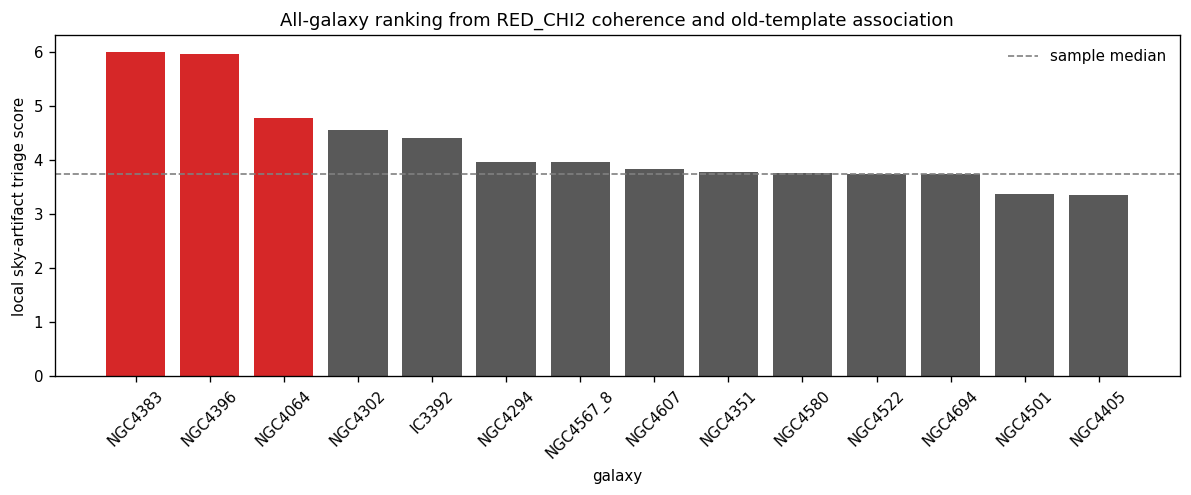

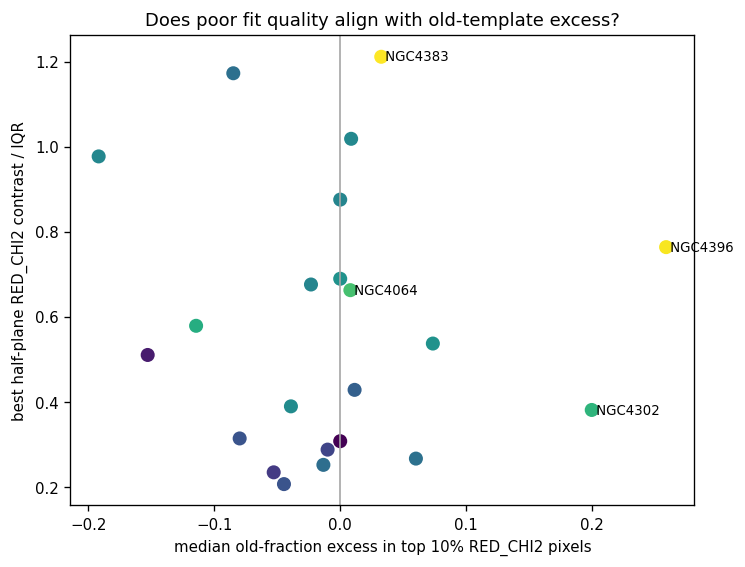

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.2))
top = summary.head(14).copy()
colors = ['tab:red' if g in FOCUS_GALAXIES else '0.35' for g in top['galaxy']]
ax.bar(top['galaxy'], top['sky_artifact_score'], color=colors)
ax.set_ylabel('local sky-artifact triage score')
ax.set_xlabel('galaxy')
ax.set_title('All-galaxy ranking from RED_CHI2 coherence and old-template association')
ax.tick_params(axis='x', rotation=45)
ax.axhline(summary['sky_artifact_score'].median(), color='0.5', lw=1, ls='--', label='sample median')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.3, 4.8))
ax.scatter(summary['old_highchi_excess'], summary['red_split_norm'], c=summary['sky_artifact_score'], cmap='viridis', s=55)
for _, row in summary.iterrows():
    if row['galaxy'] in FOCUS_GALAXIES or row['sky_artifact_score'] >= summary['sky_artifact_score'].quantile(0.85):
        ax.text(row['old_highchi_excess'], row['red_split_norm'], ' ' + row['galaxy'], fontsize=8, va='center')
ax.axvline(0, color='0.65', lw=1)
ax.set_xlabel('median old-fraction excess in top 10% RED_CHI2 pixels')
ax.set_ylabel('best half-plane RED_CHI2 contrast / IQR')
ax.set_title('Does poor fit quality align with old-template excess?')
plt.tight_layout()
plt.show()


## Focus-Galaxy Map Checks

These panels show the three galaxies from the screenshots. The old-fraction map is derived from the SFH weights. The edge-distance map is included to separate generic low-S/N/edge behavior from a coherent pointing-like split across the footprint.


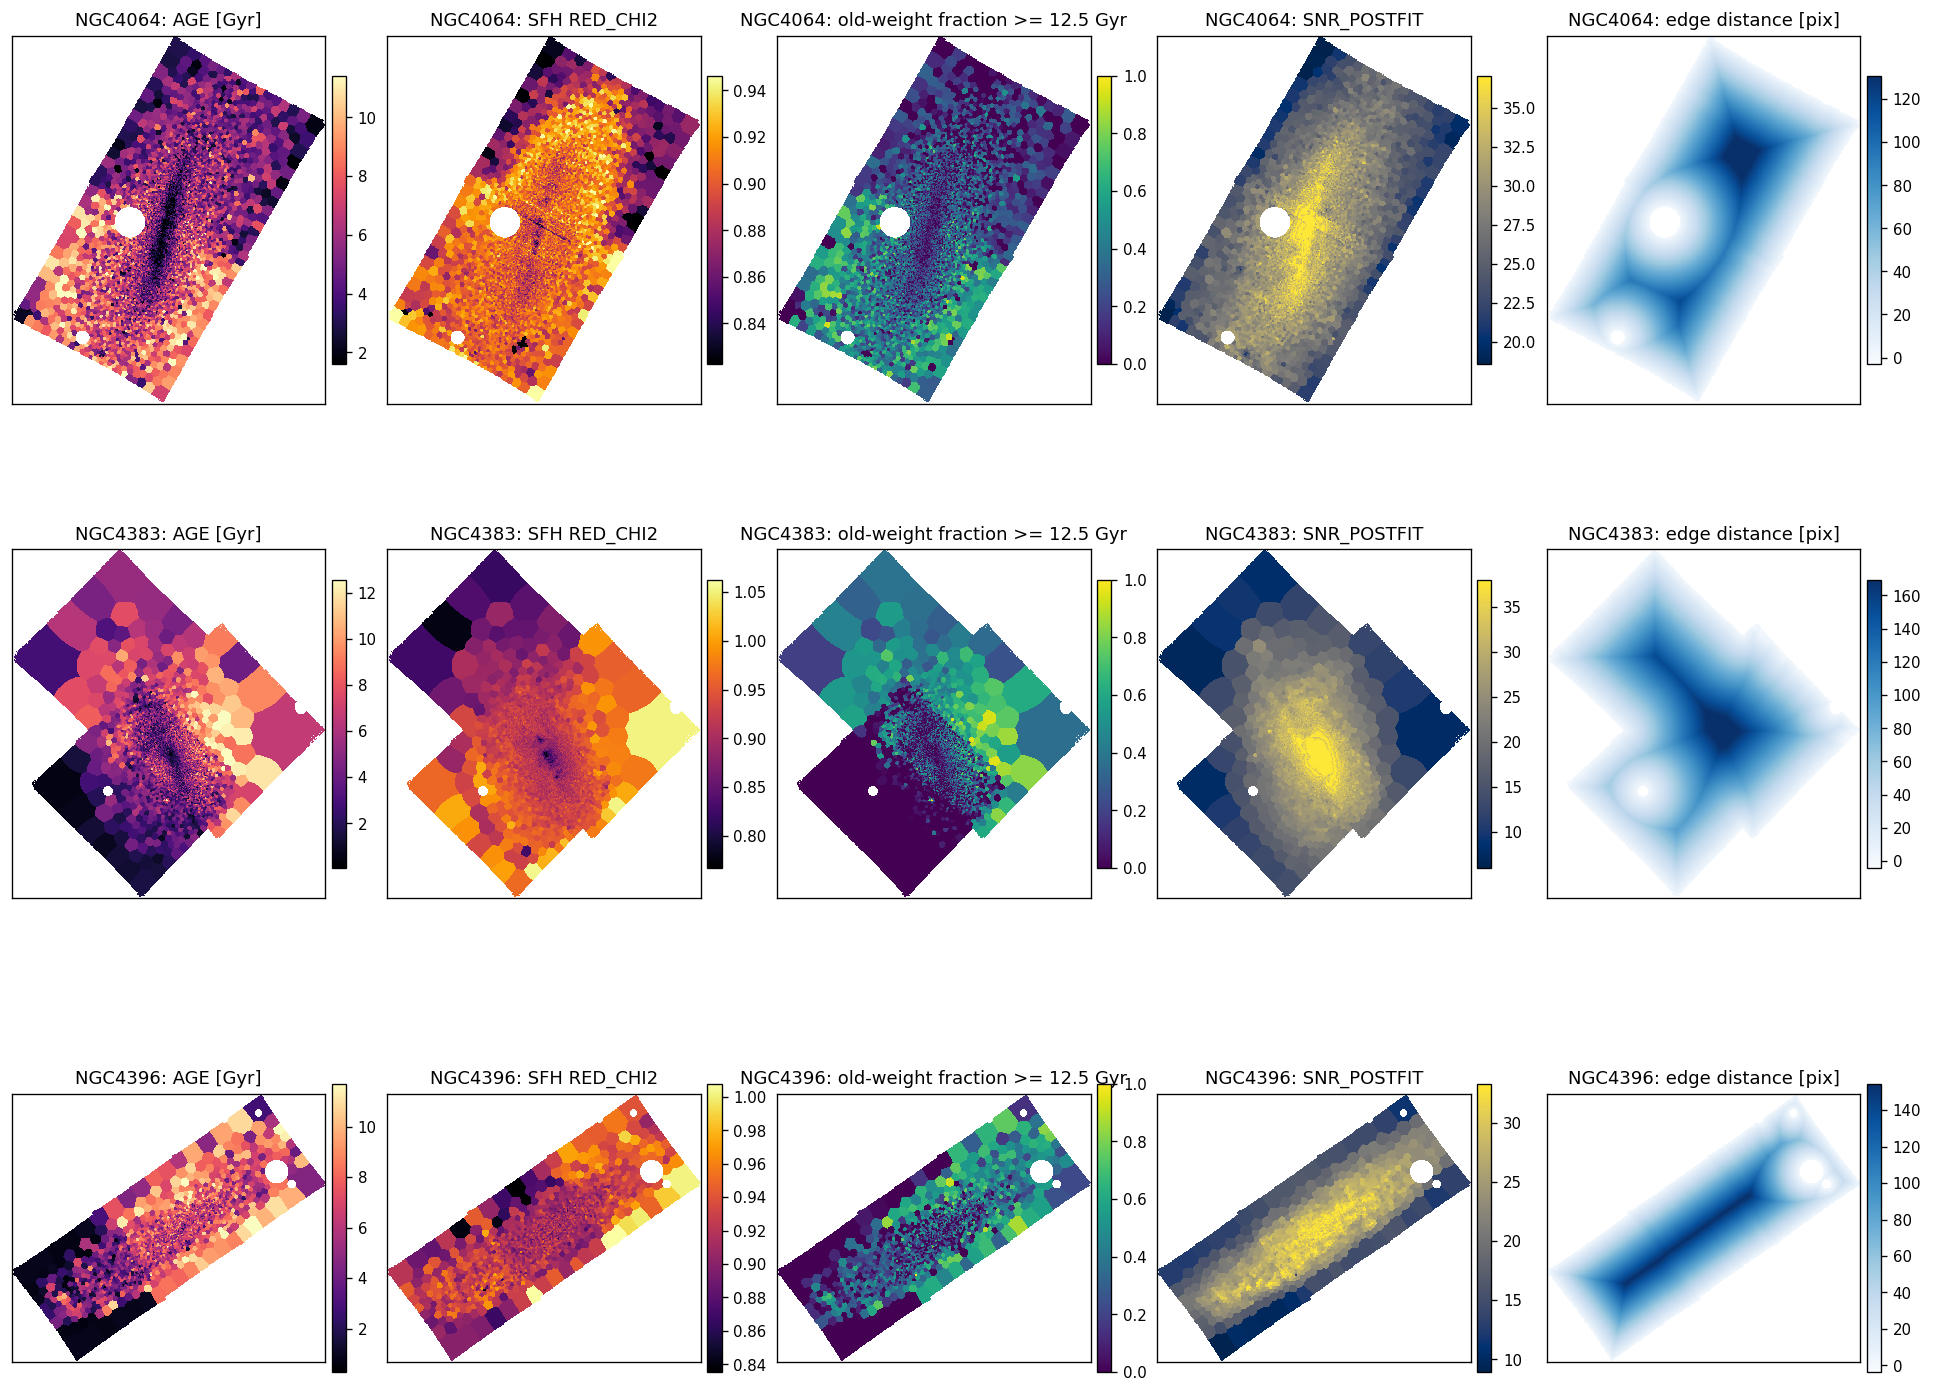

In [10]:
def show_focus_maps(galaxies=FOCUS_GALAXIES):
    fields = [
        ('AGE', 'AGE [Gyr]', 'magma'),
        ('RED_CHI2', 'SFH RED_CHI2', 'inferno'),
        ('oldfrac_map', f'old-weight fraction >= {OLD_AGE_GYR:g} Gyr', 'viridis'),
        ('SNR_POSTFIT', 'SNR_POSTFIT', 'cividis'),
        ('edge_distance_px', 'edge distance [pix]', 'Blues'),
    ]
    fig, axes = plt.subplots(len(galaxies), len(fields), figsize=(16, 4.2 * len(galaxies)), constrained_layout=True)
    if len(galaxies) == 1:
        axes = axes[None, :]
    for i, gal in enumerate(galaxies):
        arrs = arrays_by_gal[gal]
        valid = arrs['valid']
        for j, (key, title, cmap) in enumerate(fields):
            ax = axes[i, j]
            data = np.array(arrs[key], dtype=float)
            shown = np.where(valid, data, np.nan)
            if key == 'oldfrac_map':
                vmin, vmax = 0, 1
            elif key == 'edge_distance_px':
                vmin, vmax = robust_limits(shown, (2, 98))
            else:
                vmin, vmax = robust_limits(shown, (2, 98))
            im = ax.imshow(shown, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
            ax.set_title(f'{gal}: {title}')
            ax.set_xticks([])
            ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    plt.show()

show_focus_maps()


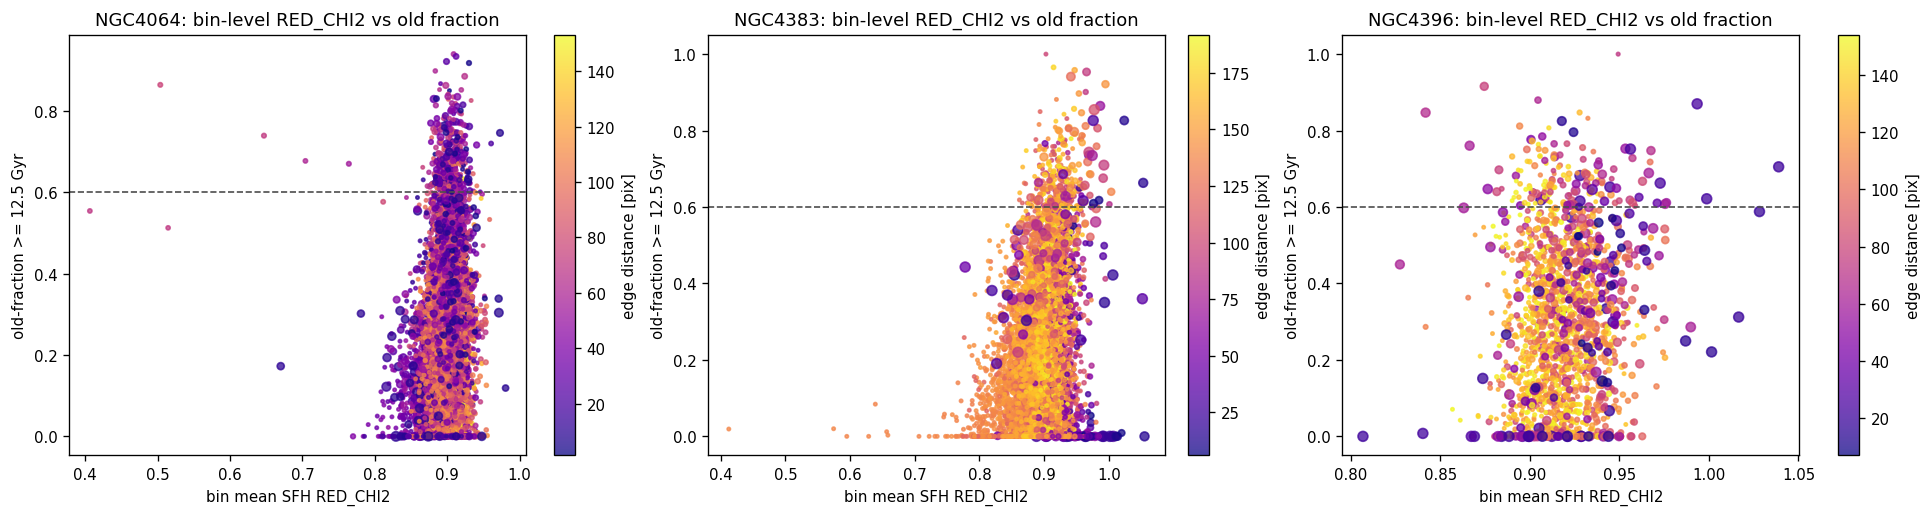

,galaxy,zone,n_pix,RED_CHI2_med,AGE_med,oldfrac_med,SNR_POSTFIT_med,EBV_med
0,NGC4064,edge_20pct,35775,0.893,5.649,0.279,23.307,0.058
1,NGC4064,core_30pct,53251,0.907,5.805,0.251,29.774,0.045
2,NGC4383,edge_20pct,45365,0.960,4.862,0.311,12.179,0.000
3,NGC4383,core_30pct,68252,0.915,7.234,0.465,25.479,0.033
4,NGC4396,edge_20pct,52308,0.933,4.819,0.221,14.640,0.134
5,NGC4396,core_30pct,78400,0.921,6.144,0.278,27.606,0.095


In [11]:
fig, axes = plt.subplots(1, len(FOCUS_GALAXIES), figsize=(16, 4.2), constrained_layout=True)
for ax, gal in zip(axes, FOCUS_GALAXIES):
    bt = bins_by_gal[gal].copy()
    bt = bt[np.isfinite(bt['redchi']) & np.isfinite(bt['oldfrac']) & (bt['bin_size_pix'] > 0)]
    edge = bt['edge_distance_px'].to_numpy()
    sc = ax.scatter(bt['redchi'], bt['oldfrac'], c=edge, s=np.clip(np.sqrt(bt['bin_size_pix']), 4, 35), cmap='plasma', alpha=0.75)
    ax.axhline(0.6, color='0.3', ls='--', lw=1)
    ax.set_xlabel('bin mean SFH RED_CHI2')
    ax.set_ylabel(f'old-fraction >= {OLD_AGE_GYR:g} Gyr')
    ax.set_title(f'{gal}: bin-level RED_CHI2 vs old fraction')
    plt.colorbar(sc, ax=ax, label='edge distance [pix]')
plt.show()

edge_tables = []
for gal in FOCUS_GALAXIES:
    arrs = arrays_by_gal[gal]
    valid = arrs['valid']
    edge = arrs['edge_distance_px']
    q20, q70 = np.nanpercentile(edge[valid], [20, 70])
    for zone, mask in [('edge_20pct', valid & (edge <= q20)), ('core_30pct', valid & (edge >= q70))]:
        edge_tables.append({
            'galaxy': gal,
            'zone': zone,
            'n_pix': int(mask.sum()),
            'RED_CHI2_med': np.nanmedian(arrs['RED_CHI2'][mask]),
            'AGE_med': np.nanmedian(arrs['AGE'][mask]),
            'oldfrac_med': np.nanmedian(arrs['oldfrac_map'][mask]),
            'SNR_POSTFIT_med': np.nanmedian(arrs['SNR_POSTFIT'][mask]),
            'EBV_med': np.nanmedian(arrs['EBV'][mask]),
        })

display(pd.DataFrame(edge_tables).style.format(precision=3))


## Half-Plane Split Diagnostics

Because the local map products do not contain an explicit pointing ID, this is a proxy for pointing-scale structure: for each map we search straight-line splits through the valid footprint and report the maximum median contrast normalized by the map IQR. This is useful for detecting large coherent halves, but it cannot prove the instrument mosaic boundary by itself.


,galaxy,red_split_norm,red_split_angle,red_split_low,red_split_high,age_split_norm,age_split_angle,age_split_low,age_split_high,old_split_norm,old_split_angle,old_split_low,old_split_high
0,NGC4383,1.211,130,0.958,0.861,0.895,30,2.829,6.742,0.861,55.000,0.000,0.443
1,NGC4396,0.764,20,0.913,0.943,1.070,15,2.602,7.964,0.798,10.000,0.045,0.451
2,NGC4064,0.663,80,0.904,0.882,0.840,65,7.982,4.889,0.831,60.000,0.447,0.175
3,NGC4302,0.381,0,0.932,0.915,0.286,0,5.866,6.868,0.482,80.000,0.316,0.107
4,IC3392,0.579,40,0.951,0.926,0.648,35,9.345,7.236,0.485,20.000,0.452,0.295
5,NGC4294,0.537,15,0.933,0.956,0.230,115,5.754,5.107,0.475,55.000,0.218,0.361
6,NGC4567_8,0.689,155,0.934,0.909,0.590,105,3.975,2.485,0.295,110.000,0.041,0.000
7,NGC4607,0.390,25,0.932,0.921,1.016,60,2.294,8.125,1.005,60.000,0.000,0.579
8,NGC4351,1.018,175,0.939,0.864,0.627,20,2.072,4.150,0.434,0.000,0.107,0.000
9,NGC4580,0.977,20,0.905,0.956,0.608,30,8.532,6.516,0.616,75.000,0.239,0.036


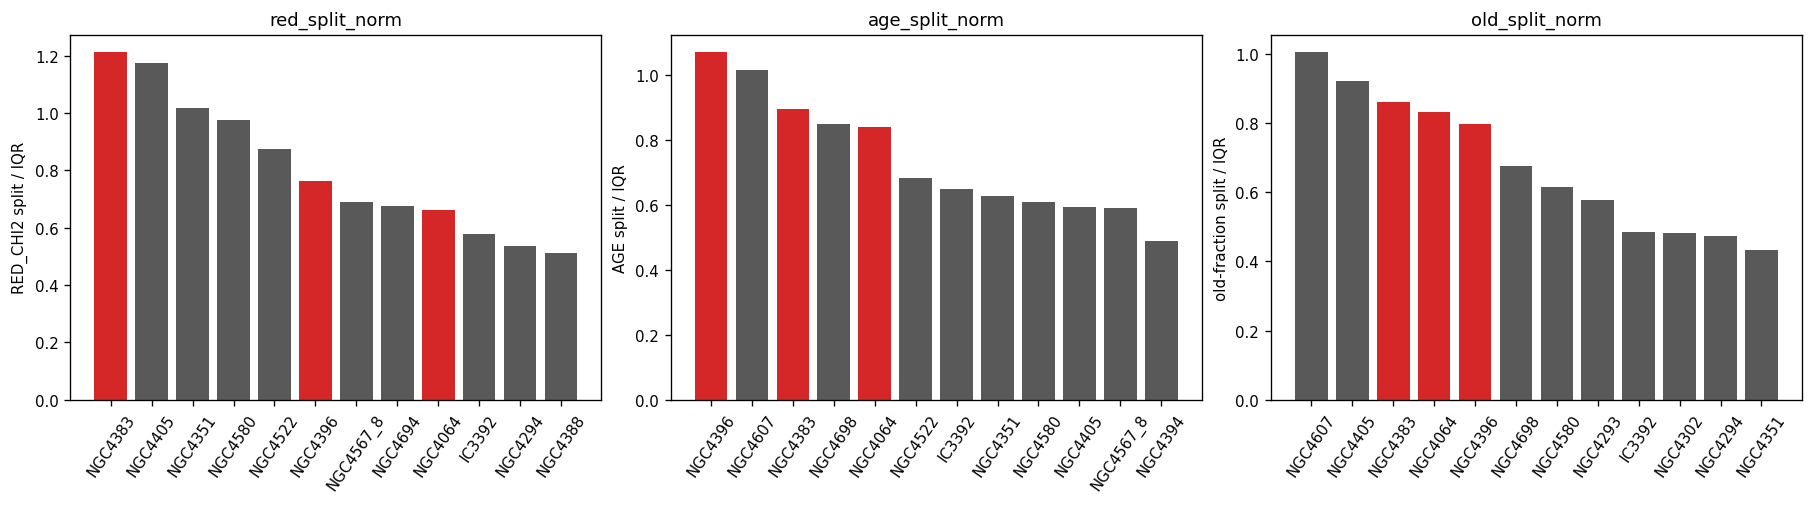

In [12]:
split_cols = [
    'galaxy',
    'red_split_norm', 'red_split_angle', 'red_split_low', 'red_split_high',
    'age_split_norm', 'age_split_angle', 'age_split_low', 'age_split_high',
    'old_split_norm', 'old_split_angle', 'old_split_low', 'old_split_high',
]
display(summary[split_cols].head(15).style.format(precision=3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.1), constrained_layout=True)
for ax, metric, ylabel in zip(
    axes,
    ['red_split_norm', 'age_split_norm', 'old_split_norm'],
    ['RED_CHI2 split / IQR', 'AGE split / IQR', 'old-fraction split / IQR'],
):
    ordered = summary.sort_values(metric, ascending=False).head(12)
    ax.bar(ordered['galaxy'], ordered[metric], color=['tab:red' if g in FOCUS_GALAXIES else '0.35' for g in ordered['galaxy']])
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=55)
    ax.set_title(metric)
plt.show()


## Interpretation Of Local Evidence

The key causal test available locally is spatial association, not spectral identification. A sky-residual explanation is strengthened when high `RED_CHI2`, old-template excess, low `SNR_POSTFIT`, and coherent half-footprint/edge structures appear together. It is weakened when `AGE`/old-template structure is not associated with `RED_CHI2` or is plausibly a normal stellar-population gradient.


In [13]:
interpret_cols = [
    'galaxy', 'sky_artifact_score', 'redchi_med', 'redchi_p95',
    'edge_redchi_delta', 'red_split_norm', 'age_split_norm', 'old_split_norm',
    'old_high_frac', 'old_highchi_excess', 'highchi_old_overlap_frac',
    'rho_redchi_old', 'rho_redchi_edge', 'rho_redchi_snr_post', 'rho_redchi_binsize', 'rho_redchi_ebv',
]
flagged = summary[
    (summary['sky_artifact_score'] >= summary['sky_artifact_score'].quantile(0.70)) |
    (summary['galaxy'].isin(FOCUS_GALAXIES))
][interpret_cols]
display(flagged.style.format(precision=3))

for gal in FOCUS_GALAXIES:
    r = summary.loc[summary['galaxy'] == gal].iloc[0]
    print(
        f"{gal}: score={r.sky_artifact_score:.3f}, RED_CHI2 p95={r.redchi_p95:.3f}, "
        f"edge_delta={r.edge_redchi_delta:.3f}, red_split={r.red_split_norm:.3f}, "
        f"age_split={r.age_split_norm:.3f}, old_split={r.old_split_norm:.3f}, "
        f"old_highchi_excess={r.old_highchi_excess:.3f}, highchi_old_overlap={r.highchi_old_overlap_frac:.3f}, "
        f"rho(redchi,SNR_POSTFIT)={r.rho_redchi_snr_post:.3f}"
    )


,galaxy,sky_artifact_score,redchi_med,redchi_p95,edge_redchi_delta,red_split_norm,age_split_norm,old_split_norm,old_high_frac,old_highchi_excess,highchi_old_overlap_frac,rho_redchi_old,rho_redchi_edge,rho_redchi_snr_post,rho_redchi_binsize,rho_redchi_ebv
0,NGC4383,6.000,0.930,1.052,0.045,1.211,0.895,0.861,0.034,0.033,0.073,0.087,-0.357,-0.715,0.747,-0.304
1,NGC4396,5.955,0.925,0.993,0.012,0.764,1.070,0.798,0.082,0.259,0.406,0.111,-0.226,-0.247,0.299,-0.151
2,NGC4064,4.773,0.899,0.932,-0.014,0.663,0.840,0.831,0.045,0.008,0.118,0.164,0.181,-0.340,0.366,-0.210
3,NGC4302,4.545,0.922,0.977,0.037,0.381,0.286,0.482,0.022,0.200,0.163,0.118,-0.359,-0.293,0.410,-0.170
4,IC3392,4.409,0.933,0.995,0.038,0.579,0.648,0.485,0.056,-0.114,0.030,0.221,-0.484,-0.534,0.666,-0.303
5,NGC4294,3.955,0.941,0.998,0.038,0.537,0.230,0.475,0.033,0.073,0.000,0.178,-0.129,-0.550,0.681,-0.209
6,NGC4567_8,3.955,0.918,0.970,0.019,0.689,0.590,0.295,0.002,0.000,0.006,0.140,-0.166,-0.447,0.624,-0.130


NGC4064: score=4.773, RED_CHI2 p95=0.932, edge_delta=-0.014, red_split=0.663, age_split=0.840, old_split=0.831, old_highchi_excess=0.008, highchi_old_overlap=0.118, rho(redchi,SNR_POSTFIT)=-0.340
NGC4383: score=6.000, RED_CHI2 p95=1.052, edge_delta=0.045, red_split=1.211, age_split=0.895, old_split=0.861, old_highchi_excess=0.033, highchi_old_overlap=0.073, rho(redchi,SNR_POSTFIT)=-0.715
NGC4396: score=5.955, RED_CHI2 p95=0.993, edge_delta=0.012, red_split=0.764, age_split=1.070, old_split=0.798, old_highchi_excess=0.259, highchi_old_overlap=0.406, rho(redchi,SNR_POSTFIT)=-0.247


## Practical nGIST/pPXF Follow-Up Tests

Recommended order, based on this local map-level diagnosis, the frame-convention check above, and the method references:

1. **Clean 4800-7000 control with current v7.6.8 settings held fixed.** The most decisive test is not the old 7000 comparison if it also changed velscale, template library, polynomial degree, gas setup, or binning. Make a new control where only `SFH.LMAX`/input wavelength coverage changes as much as practical.
2. **Observed-to-rest corrected skyline mask test.** If the suspicious feature is identified in mapviewer at observed wavelength, convert it to rest-frame for each galaxy/target redshift before creating the nGIST `SPEC_MASK` row. For example, observed `8103 A` is not rest `8103 A` for NGC4064; it is near `8103/(1+0.003025) = 8078.6 A`.
3. **Targeted red-region masking test.** Keep the full 4800-8900 range but widen masks around locally suspicious red skyline complexes after applying the observed-to-rest conversion. The current `specMask_KIN_narrow10` masks rest-frame 8102-8103 A, so it may miss an observed 8103 A residual in positive-redshift galaxies.
4. **Aggressive red-sky band mask or red-weight downweighting test.** If the artifact tracks `RED_CHI2`/old fraction but survives targeted masks, test a broader mask over the worst red complexes or inflate the noise in red skyline windows. This tests whether the SFH solution is being over-constrained by contaminated red pixels.
5. **pPXF sky-template route only after masking/redcut tests.** pPXF supports sky spectra in the fit, but nGIST-side integration needs real sky vectors and careful validation. This is a heavier change than a controlled redcut or mask experiment.
6. **Avoid changing regularization first.** The 14 Gyr spikes are probably a symptom of the fit using extreme SSP weights to absorb spectral-shape/residual errors. Raising `REGUL` may hide spikes but would not prove or remove the contaminating source.


## Detailed Conclusion

**Current local evidence supports sky contamination as a plausible and likely contributor, but it is not yet a direct proof of the specific `~8103 A` feature.** The strongest evidence is spatial and statistical: the full 4800-8900 SFH maps show coherent high-`RED_CHI2`/large-scale split behavior in the same family of products where the old-population weight sometimes jumps toward the oldest templates. The local products are maps and weights; they do not include the SFH bestfit spectra or `GOODPIX`, so this notebook cannot localize the causal residual to one wavelength. That missing spectral layer is the main caveat.

The frame-convention check is important. Mapviewer wavelengths are observed-frame, while the nGIST masks in this setup are rest-frame. Therefore an observed `8103 A` residual should be masked at `8103/(1+z)` in the rest-frame mask. For NGC4064 this is near `8078.6 A`, while the current rest-frame `8102-8103 A` sky mask would target an observed feature near `8127 A`. This makes the earlier direct comparison to the rest-frame 8102-8103 mask misleading, and it strengthens the case for an observed-to-rest corrected mask experiment.

For the screenshot galaxies, the automated local ranking puts **NGC4383** and **NGC4396** among the strongest sky-artifact candidates. NGC4383 has the largest half-plane `RED_CHI2` contrast in this sample and a strong anti-correlation between `RED_CHI2` and `SNR_POSTFIT`, consistent with poor fits becoming worse in lower-quality/coherent regions. NGC4396 has a strong association between high-`RED_CHI2` pixels and old-template weight: in the current maps, the old-fraction excess in high-`RED_CHI2` pixels is large and the overlap with old-dominated bins is high. **NGC4064 is more nuanced:** the global automated score is moderate because the simple edge-vs-core `RED_CHI2` statistic is not high, but the half-plane AGE and old-fraction splits are clear enough that it remains a focused suspect. This matches the visual concern that a pointing-scale AGE artifact exists even if the scalar edge metric does not capture the exact mosaic boundary.

The literature/method check is consistent with this interpretation. ESO explicitly notes that sky-subtracted MUSE cubes may retain sky-line residuals redward of 7000 A, while pPXF/GIST can only return reliable SFH weights when the fitted pixels and errors represent the real spectrum. pPXF supports `goodpixels`/masking, iterative clipping, regularization, and optional sky spectra. In this setup, however, the relevant mask wavelengths must be checked in the correct frame before concluding that a skyline is already masked.

**Recommended next minimal tests:** first run a clean `LMAX=7000` control with current v7.6.8 settings otherwise held fixed; second run a full-range 4800-8900 test with broader targeted masks over the red skyline complexes after converting observed mapviewer residual wavelengths to rest frame for each galaxy; third test broader red skyline downweighting or masking if the targeted mask helps but does not remove the pointing artifact. Only if those fail should we invest in a pPXF sky-template implementation, because that requires local sky spectra and more validation. Regularization changes should be treated as a presentation/stability diagnostic, not as the primary fix, because stronger smoothing can suppress 14 Gyr spikes without correcting the contaminated pixels.
